In [43]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import StatevectorSimulator, QasmSimulator, Aer
from qiskit.quantum_info import Statevector, partial_trace
from qiskit.visualization import visualize_transition, plot_histogram, circuit_drawer, plot_bloch_multivector, plot_state_qsphere
import numpy as np
import math as m
import random
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [44]:
# set up the simulators
S_simulator = StatevectorSimulator()
M_simulator = QasmSimulator()

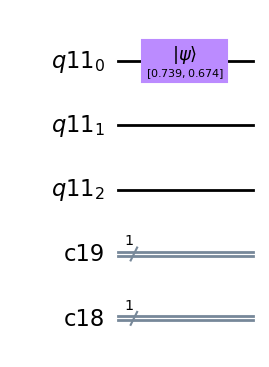

In [45]:
qr = QuantumRegister(3)
cl_x = ClassicalRegister(1)
cl_z = ClassicalRegister(1)
teleport_circuit = QuantumCircuit(qr, cl_z, cl_x)

alpha = np.random.rand()
beta = np.sqrt(1-alpha**2)

psi = Statevector([alpha, beta])
teleport_circuit.initialize(psi, 0)

teleport_circuit.draw('mpl')


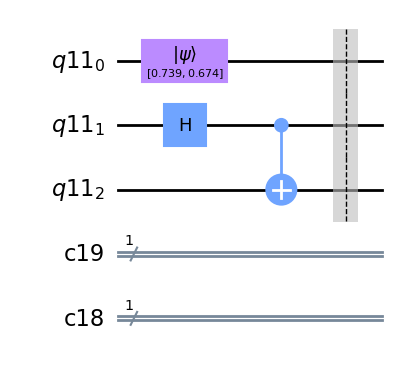

In [46]:
# entangle Anita and Bharat qubits

teleport_circuit.h(1)
teleport_circuit.cx(1, 2)
teleport_circuit.barrier()

teleport_circuit.draw('mpl')


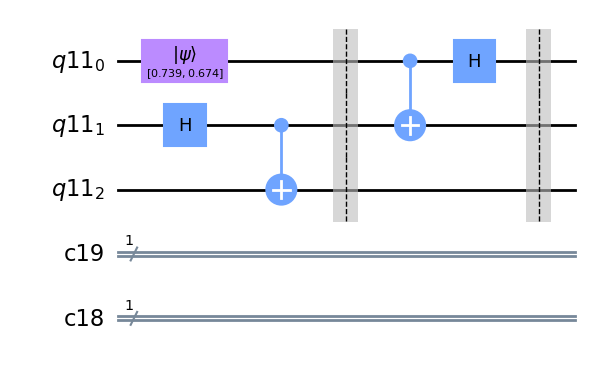

In [47]:
teleport_circuit.cx(0,1)
teleport_circuit.h(0)
teleport_circuit.barrier()
teleport_circuit.draw('mpl')


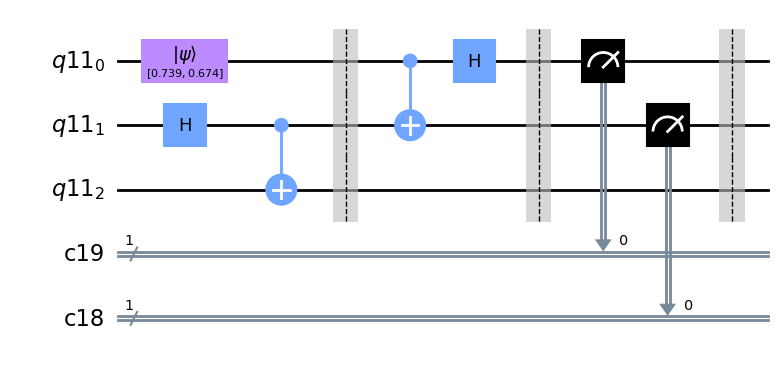

In [48]:
teleport_circuit.measure(0, 0)
teleport_circuit.measure(1, 1)
teleport_circuit.barrier()
teleport_circuit.draw('mpl')

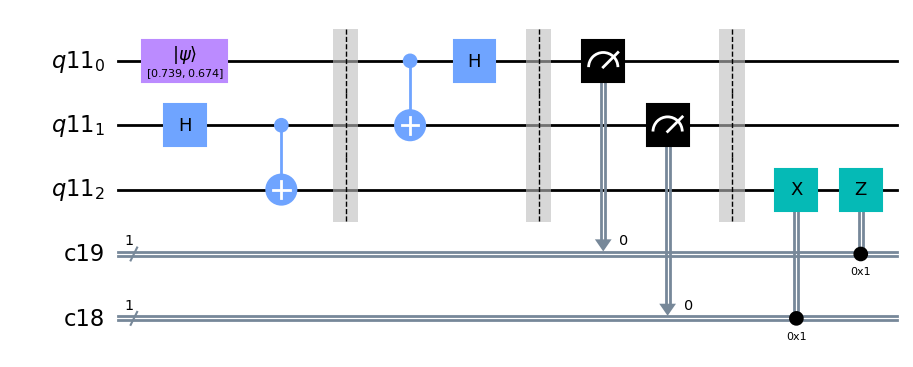

In [49]:
teleport_circuit.x(2).c_if(cl_x, 1)
teleport_circuit.z(2).c_if(cl_z, 1)
teleport_circuit.draw('mpl')

In [50]:
job = S_simulator.run(teleport_circuit)
result = job.result()
teleported_state = result.get_statevector(teleport_circuit)
#print(teleported_state)

red_rho = partial_trace(teleported_state, [0, 1])
#print(red_rho)

state_vector_bharat_qubit = red_rho.data.diagonal()

print("Alpha: ", np.sqrt(state_vector_bharat_qubit[0]))
print("Beta: ", np.sqrt(state_vector_bharat_qubit[1]))


Alpha:  (0.7390061575798497+0j)
Beta:  (0.6736986708158672-2.1900065416031593e-33j)
